# Feature Selection

In [1]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Exploratory Data Analysis

In [ ]:
# Total auth events per user
events_per_user = (
    df
    .group_by("src_user")
    .agg(total_events=pl.len())
    .collect()
)

auth_counts = events_per_user["total_events"].to_numpy()

Text(0, 0.5, 'Frequency')

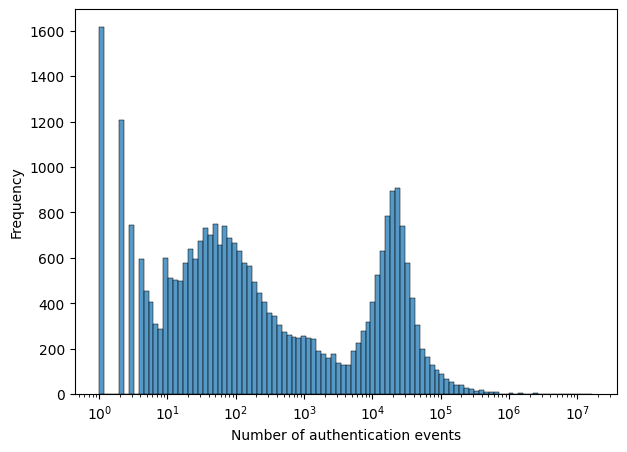

In [ ]:
# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(auth_counts, log_scale=True, bins = 100)
plt.xlabel('Number of authentication events')
plt.ylabel('Frequency')

In [ ]:
# Number of distinct source computers per user
distinct_src_comps = (
    df
    .group_by('src_user')
    .agg(total = pl.col('src_comp').n_unique())
    .collect()
)

src_comp_counts = distinct_src_comps["total"].to_numpy()

Text(0, 0.5, 'Frequency')

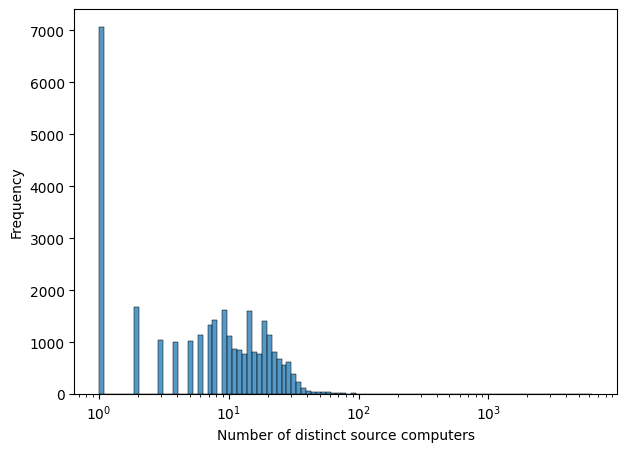

In [ ]:
# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(src_comp_counts, log_scale=True, bins = 100)
plt.xlabel('Number of distinct source computers')
plt.ylabel('Frequency')

In [ ]:
# Number of distinct destination computers per user
distinct_dest_comps = (
    df
    .group_by('src_user')
    .agg(total = pl.col('dest_comp').n_unique())
    .collect()
)

dest_comp_counts = distinct_dest_comps["total"].to_numpy()

Text(0, 0.5, 'Frequency')

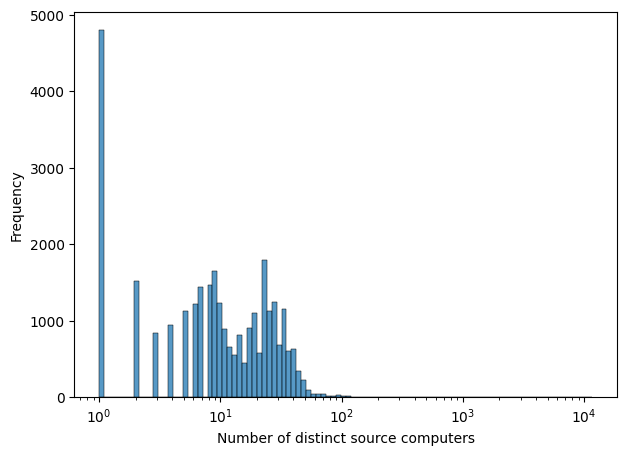

In [ ]:
# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(dest_comp_counts, log_scale=True, bins = 100)
plt.xlabel('Number of distinct source computers')
plt.ylabel('Frequency')

In [59]:
# Number of distinct destination computers per user
distinct_dest_users = (
    df
    .group_by('src_user')
    .agg(total = pl.col('dest_user').n_unique())
    .collect()
)

dest_user_counts = distinct_dest_users["total"].to_numpy()

Text(0, 0.5, 'Frequency')

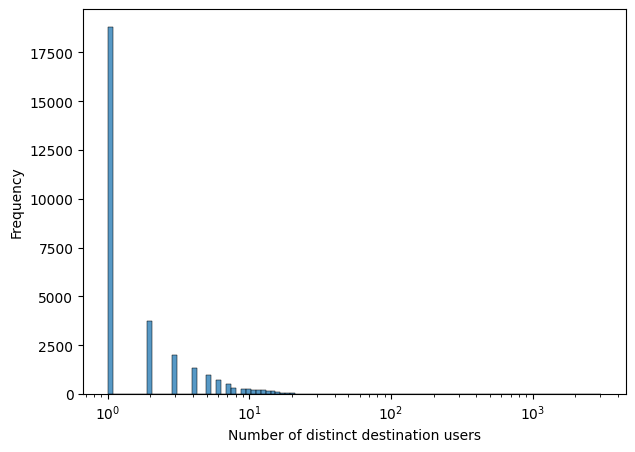

In [60]:
# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(dest_user_counts, log_scale=True, bins = 100)
plt.xlabel('Number of distinct destination users')
plt.ylabel('Frequency')

In [ ]:
# Distribution of failure rates
user_failures = (
    df
    .with_columns(is_fail = pl.col("outcome") == "Fail")
    .group_by("src_user")
    .agg(failure_rate = pl.col("is_fail").mean())
    .collect()
)

failure_rates = user_failures["failure_rate"].to_numpy()

Text(0, 0.5, 'Frequency')

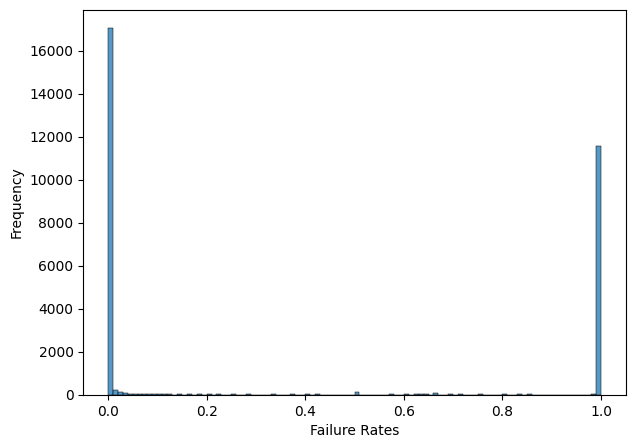

In [62]:
# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(failure_rates, bins = 100)
plt.xlabel('Failure Rates')
plt.ylabel('Frequency')

## Feature Construction

In [4]:
df.show(5)

time,src_user,dest_user,src_comp,dest_comp,auth_type,logon_type,auth_orientation,outcome
i64,str,str,str,str,str,str,str,str
1,"""U101@DOM1""","""C1862$@DOM1""","""C1862""","""C1862""","""?""","""?""","""AuthMap""","""Success"""
1,"""U101@DOM1""","""U101@DOM1""","""C1862""","""C1862""","""Negotiate""","""Interactive""","""LogOn""","""Success"""
1,"""U10@DOM1""","""U10@DOM1""","""C229""","""C229""","""Kerberos""","""Network""","""LogOn""","""Success"""
1,"""U10@DOM1""","""U10@DOM1""","""C62""","""C528""","""Kerberos""","""Network""","""LogOn""","""Success"""
1,"""U1137@DOM1""","""U1137@DOM1""","""C1065""","""C1065""","""?""","""Network""","""LogOff""","""Success"""


In [6]:
df = df.select(['time','src_user','src_comp','dest_comp','outcome'])

In [7]:
df.show(5)

time,src_user,src_comp,dest_comp,outcome
i64,str,str,str,str
1,"""U101@DOM1""","""C1862""","""C1862""","""Success"""
1,"""U101@DOM1""","""C1862""","""C1862""","""Success"""
1,"""U10@DOM1""","""C229""","""C229""","""Success"""
1,"""U10@DOM1""","""C62""","""C528""","""Success"""
1,"""U1137@DOM1""","""C1065""","""C1065""","""Success"""
